# Transmitter and Receivers
## LAB 3
In this laboratory we will implement a FM receiver based on a frequency discrimination technique. For that purpose we will use our data gathered from GNU Radio and implement the complete FM receiver stack.

In [1]:
import numpy as np
import scipy
import scipy.signal as signal
from scipy.io.wavfile import write
import matplotlib.pyplot as plt

In [2]:
def spectogram(data, Fs, title='Spectogram of Signal'):
    ''' Function to plot signal spectogram
    '''
    plt.specgram(data, NFFT =1024, Fs=Fs)
    plt.title(title)
    plt.xlabel("Time")
    plt.ylabel("Frequency")

def psd(data, Fs, title='PSD of Signal'):
    ''' Function to plot the power spectral density of a signal
    '''
    plt.psd(data, NFFT=1024, Fs=Fs)
    plt.title(title)

def normalize(data):
    ''' Function to normalize between range of [-1 to 1]
    '''
    calculate_range = max(data) - min(data)
    normalized_data = (data - min(data))/ calculate_range
    return (normalized_data*2) - 1

def frequency_shift(data, Fs, fc):
    ''' Function to perform a frequency shift of a given signal
    '''
    N = len(data)
    data_fc = np.exp(-1.0j*2.0*np.pi* fc/Fs*np.arange(N))
    return data*data_fc


def low_pass_filter(data, Fs, f_bw, n_taps):
    ''' Function to to perform a low pass filtering of a signal
    '''
    lpf= signal.remez(n_taps, [0, f_bw, f_bw +(Fs/2-f_bw)/4,Fs/2], [1,0], Hz=Fs)
    lpf_data = signal.lfilter(lpf, 1.0, data)
    w,h = signal.freqz(lpf)
    return lpf_data, [w, h]


def filter_response(w, h):
    ''' Function to plot the logarithmic response of a digital filter
    '''
    plt.plot(w, 20*np.log10(abs(h)))
    plt.xscale('log')
    plt.title('Filter Frequency Response')
    plt.xlabel('Frequency')
    plt.ylabel('Amplitude')
    plt.margins(0,1)
    plt.grid(which='both',axis='both')
    
    
def plot_constellation(data):
    ''' Function to plot the I/Q constellation of a signal
    '''
    plt.scatter(np.real(data), np.imag(data))
    plt.title('Signal Constellation')
    plt.xlabel('I')
    plt.ylabel('Q')
    
    
def decimate(data, dec_rate):
    ''' Function to perform decimation of given signal.
    '''
    return signal.decimate(data, dec_rate)


def rational_resampler(data, dec_rate, interp_rate):
    ''' Function to perform decimation and interpolation of given signal.
    '''
    return signal.resample_poly(data, interp_rate, dec_rate)


def frequency_discriminator(data):
    ''' Function to perform an FM demodulator 
    based on a frequency discriminator process.
    '''
    data_real_comp = data[1:] * np.conj(data[:-1])
    return np.angle(data_real_comp)


def de_emphasis_filter(data, Fs, tau=75e-6):
    ''' Function to apply a de-emphasis filter to the input signal.
    '''
    d = Fs*tau   # Calculate the # of samples to hit the -3dB point
    r = np.exp(-1/d)   # Calculate the decay between each sample
    b = [1-r]          # Create the filter coefficients
    a = [1,-r]
    return signal.lfilter(b,a,data)


def write_raw_file(data, volume=10000, file_name='audio_reconstruct.raw'):
    ''' Function to save the received signal in a raw format.
    '''
    max_value = np.max(np.abs(data))
    data_to_write = data*(volume/max_value) # scale so it's audible
    data_to_write.astype("int16").tofile(file_name)
    
def write_wav_file(data, volume=10000, Fs=24e3, file_name='audio_reconstruct.wav'):
    ''' Function to save the received signal in an audio wav format.
    '''
    max_value = np.max(np.abs(data))
    data_to_write = data*(volume/max_value) # scale so it's audible
    write(file_name, Fs, data_to_write.astype(np.int16))

In [3]:
# Import our raw data gathered from the LimeSDR
data = np.fromfile(open("received.raw"), dtype=scipy.complex64)

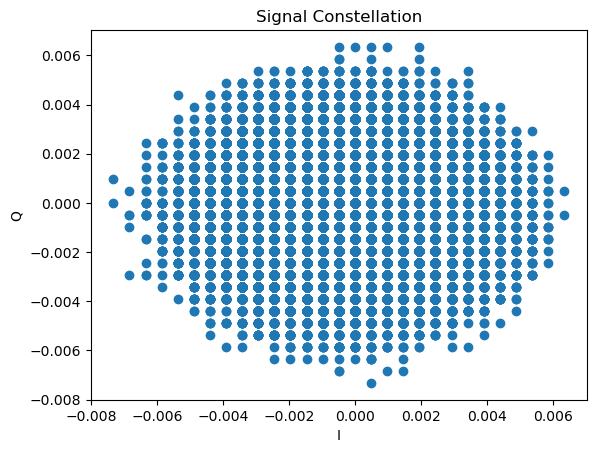

In [4]:
# Plot the signal constellation I/Q
plot_constellation(data)

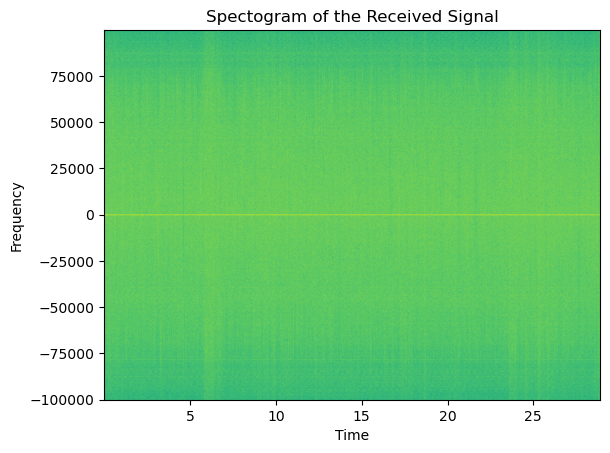

In [5]:
#Plot the spectogram of the received signal 
Fs = 200e3
spectogram(data, Fs, title='Spectogram of the Received Signal')

In [6]:
Fs = 200e3
fc_filter = 80e3
taps = 64


x1 = normalize(data)
x2 = frequency_shift(x1, Fs, 0)
x3, [w, h] = low_pass_filter(x2, Fs, fc_filter, taps)

x4 = frequency_discriminator(x3)

dec_rate_1 = 10
Fs_x5 = Fs/dec_rate_1
x5 = decimate(x4, dec_rate_1)


x6 = de_emphasis_filter(x5, Fs_x5)    

dec_rate_2 = 20
interp_rate = 24
x7 = rational_resampler(x6, dec_rate_2, interp_rate)

write_raw_file(x7, volume=10000, file_name='audio_reconstruct.raw')    
write_wav_file(x7, volume=10000, Fs=24000, file_name='audio_reconstruct.wav')

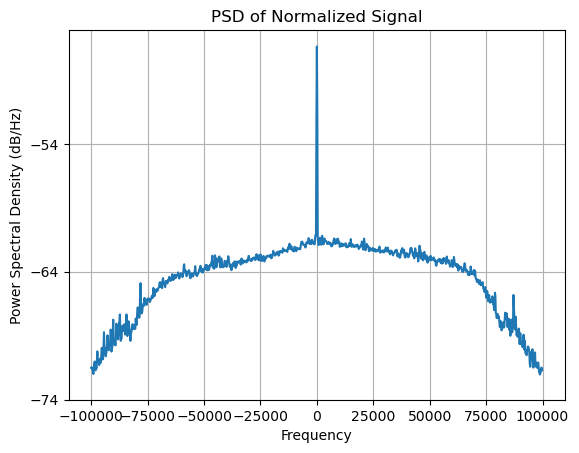

In [7]:
# Normalized Signal
psd(x1, Fs, title='PSD of Normalized Signal')

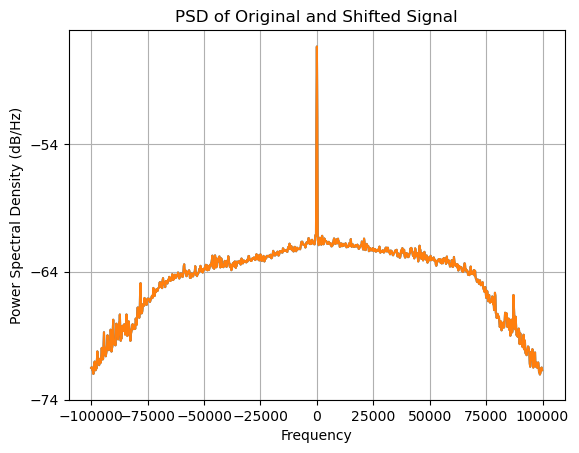

In [8]:
# Frequency Shift Signal
psd(x1, Fs)
psd(x2, Fs, title='PSD of Original and Shifted Signal')

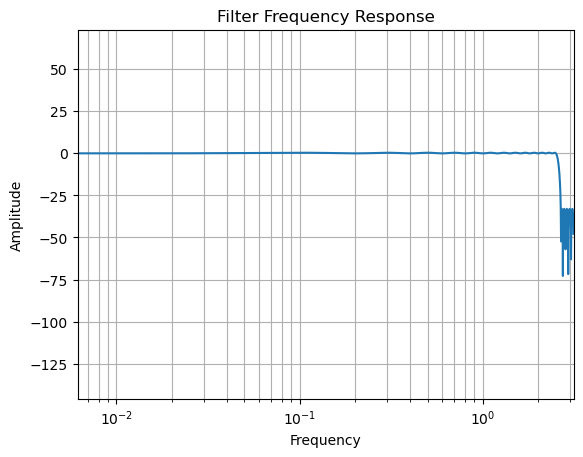

In [9]:
# Filter Response
filter_response(w, h)

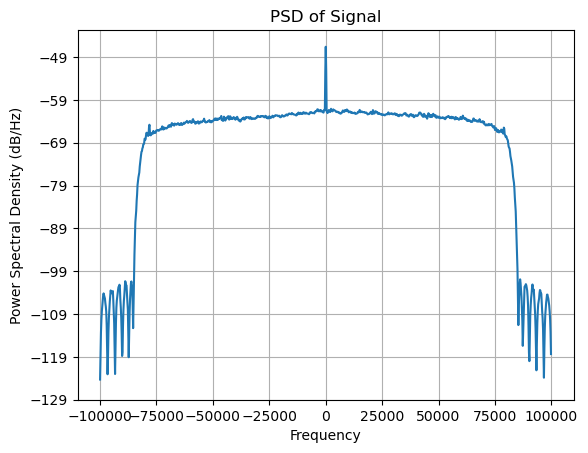

In [10]:
# Filtered Signal
psd(x3, Fs)

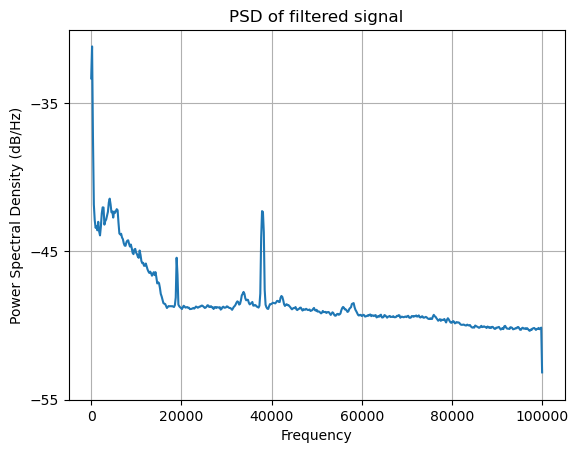

In [11]:
#Frequency Discriminator
psd(x4, Fs, title='PSD of filtered signal')

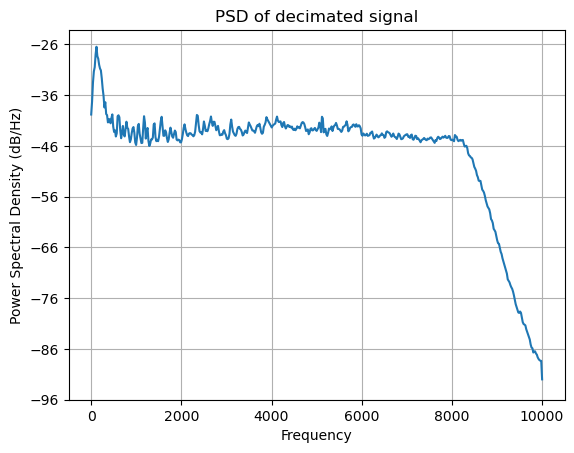

In [12]:
# Decimated Signal
psd(x5, Fs_x5, title='PSD of decimated signal')

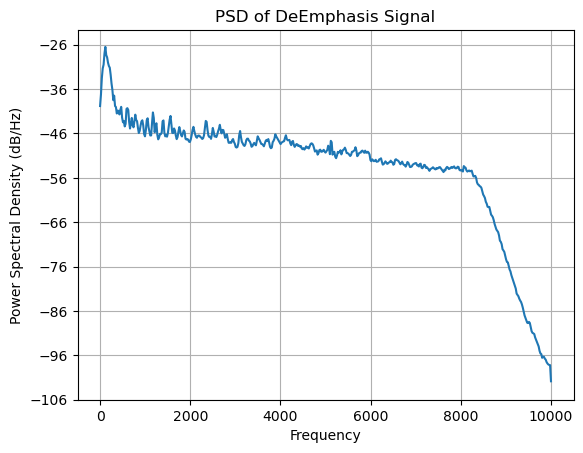

In [13]:
# DeEmphasis Signal
psd(x6, Fs_x5, title='PSD of DeEmphasis Signal')

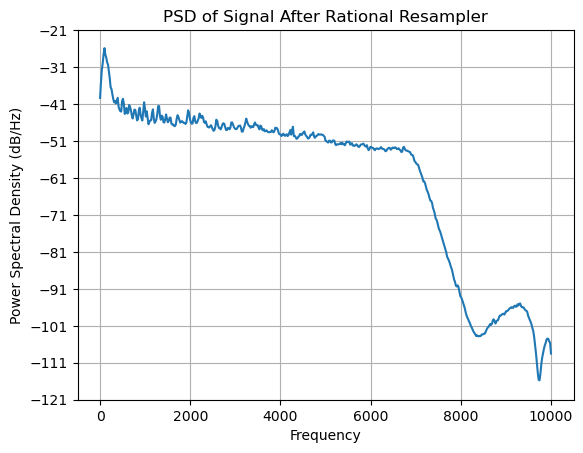

In [14]:
# Rational Resampler (This is the final signal recoverd)
psd(x7, Fs_x5, title='PSD of Signal After Rational Resampler')